In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
def BS(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

In [3]:
def vega(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return S0 * np.sqrt(T) * norm.pdf(d1)

def vol_impli_newton(S0, K, T, r, C):
    sigma = 0.2
    while (np.abs(cbs := BS(S0, K, T, r, sigma) - C) > 1e-6):
        sigma = sigma - (BS(S0, K, T, r, sigma) - C)/vega(S0, K, T, r, sigma)
    return sigma

def vol_impli_bisection(S0, K, T, r, C):
    sigma = 0.2
    cbs = BS(S0, K, T, r, sigma)
    if cbs < C:
        sigma_bas = sigma
        sigma_haut = 2*sigma
        while (BS(S0, K, T, r, sigma_haut) < C) and (sigma_haut < 5):
            sigma_haut *= 2
        if sigma_haut >= 5:
            raise ValueError('Wrong Option Price')
    else:
        sigma_haut = sigma
        sigma_bas = sigma/2
        while (BS(S0, K, T, r, sigma_bas) > C) and (sigma_bas > 0.001):
            sigma_bas /= 2
        if sigma_bas <= 0.001:
            raise ValueError('Wrong Option Price')

    sigma = (sigma_bas + sigma_haut)/2.
    cbs = BS(S0, K, T, r, sigma)
    while np.abs(cbs - C) > 1e-6:
        if cbs < C:
            sigma_bas = sigma
        else:
            sigma_haut = sigma
        sigma = (sigma_bas + sigma_haut)/2.
        cbs = BS(S0, K, T, r, sigma)

    return sigma

def vol_impli(S0, K, T, r, C):
    try:
        sigma = vol_impli_newton(S0, K, T, r, C)
    except Exception:
        sigma = vol_impli_bisection(S0, K, T, r, C)
    return sigma

In [4]:
S0 = 10
K = 6
T = 1
r = 0.05
sigma = 0.2
C = BS(S0, K, T, r, sigma)
C

np.float64(4.293752745972149)

In [5]:
vol_impli_bisection(S0, K, T, r, C)

0.19998779296875002

In [6]:
def Heston_MC(S0, v0, K, T, r, kappa, theta, xi, rho, nb_MC = 10000, nb_t = 5001):
    np.random.seed(12)
    dt = T/(nb_t-1)
    dWts = np.sqrt(dt) * np.random.normal(0, 1, [nb_MC,nb_t-1])
    dWts_2 = np.sqrt(dt) * np.random.normal(0, 1, [nb_MC,nb_t-1])
    dBts = rho * dWts + np.sqrt(1-rho**2) * dWts_2
    Ss = S0 * np.ones(nb_MC)
    vs = v0 * np.ones(nb_MC)
    for n in range(nb_t-1):
        Ss += r * Ss * dt + np.sqrt(vs) * Ss * dWts[:,n]
        vs += kappa*(theta - vs) * dt + xi * np.sqrt(vs) * dBts[:,n]
        vs = np.maximum(vs, 0.)
    return np.exp(-r*T) * np.mean(np.maximum(Ss - K, 0.))

In [7]:
sigma = 0.2
v0 = sigma**2
kappa = 0.5
xi = 0.3
theta = 0.2**2
rho = -0.5
S0=10
K=10
T=1
r=0.05
BS(S0, K, T, r, sigma), Heston_MC(S0, v0, K, T, r, kappa, theta, xi, rho)

(np.float64(1.045058357218557), np.float64(1.0249732874733595))

In [37]:
ms = np.arange(0.7, 1.5, 0.05)
Ks = S0 * ms
sigma_implis = []
for K in Ks:
    print(K)
    C = Heston_MC(S0, v0, K, T, r, kappa, theta, xi, rho)
    sigma_impli = vol_impli_bisection(S0, K, T, r, C)
    sigma_implis.append(sigma_impli)

7.0
7.5
8.0
8.5
9.000000000000002
9.500000000000002
10.000000000000002
10.500000000000004
11.000000000000004
11.500000000000004
12.000000000000004
12.500000000000004
13.000000000000005
13.500000000000005
14.000000000000005
14.500000000000007


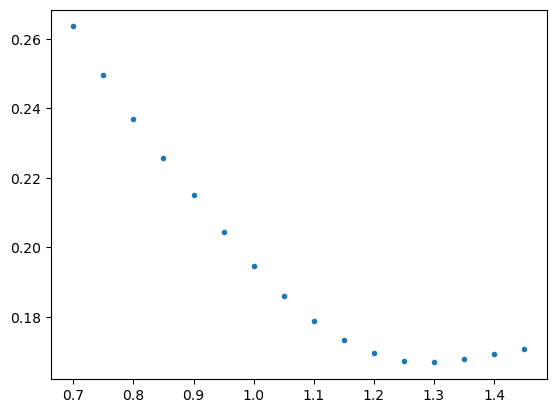

In [38]:
plt.plot(ms, sigma_implis, '.')
plt.show()